# Peak/Off-peak & Arbitrage Analysis

Produces figures and tables for chapters 7–8 of the thesis:

- **Chapter 7 (price structure):** `fig_daily_spread_change_bat{2,4,8}` (DE00 + EU), `fig_capture_rates_line`
- **Chapter 8 (economics):** `fig_lcos_de00`, `fig_lcos_mega`, `fig_lcos_zoom`, `fig_de00_daily_profile_curves` + `_areas`

Peak hours are defined by the EPEX standard: 08–20h on weekdays. Off-peak is everything else.


## Setup

Loads all solved scenario outputs (LMP, generator dispatch, storage charge/discharge) and classifies each hour as peak or off-peak.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys
sys.path.append('../scenario_analysis')
from plot_utils import (
    apply_thesis_style, thesis_subplots, save_fig,
    CARRIER_COLORS, SCALE_COLORS, SCALE_MARKERS, SCALE_LABELS, CY_LABELS,
    POSITIVE, NEGATIVE, NEUTRAL, REFLINE,
)
apply_thesis_style()

ROOT = Path(".").resolve().parent
DATA = ROOT / "data" / "tyndp2024" / "preprocessed" / "solved"

# === Load ALL data once ===
results = pd.read_csv(ROOT / "solved_networks_core" / "solve_results.csv")
results = results[results["status"] == "solved"].copy()

static_gen = pd.read_parquet(DATA / "static_generators.parquet")
static_su = pd.read_parquet(DATA / "static_storage_units.parquet")

print("Loading lmp.parquet...")
lmp_all = pd.read_parquet(DATA / "lmp.parquet")
bus_cols = [c for c in lmp_all.columns if c not in ("tag", "timestamp")]

print("Loading gen_p.parquet...")
gen_p_all = pd.read_parquet(DATA / "gen_p.parquet")
gen_cols = [c for c in gen_p_all.columns if c not in ("tag", "timestamp")]

print("Loading storage_p.parquet...")
stor_p_all = pd.read_parquet(DATA / "storage_p.parquet")
stor_cols = [c for c in stor_p_all.columns if c not in ("tag", "timestamp")]

# Peak/off-peak classification
def classify_peak(timestamps):
    """Return boolean array: True = peak (08-20 Mon-Fri)."""
    ts = pd.to_datetime(timestamps)
    return (ts.dt.hour >= 8) & (ts.dt.hour < 20) & (ts.dt.weekday < 5)

lmp_all["is_peak"] = classify_peak(lmp_all["timestamp"])

# Corridors for tail dependence
CORRIDORS = [
    ("DE00", "FR00"), ("DE00", "NL00"), ("DE00", "PL00"), ("DE00", "AT00"),
    ("FR00", "ES00"), ("FR00", "BE00"), ("FR00", "GB00"), ("NOS0", "DE00"),
    ("SE01", "FI00"), ("DE00", "CZ00"), ("ITN1", "AT00"), ("DKW1", "DE00"),
]
CORRIDOR_LABELS = [f"{a}\u2013{b}" for a, b in CORRIDORS]

KEY_CARRIERS = ["solar-pv-utility", "onwind", "offwind", "gas", "nuclear", "hydro-ror"]

print(f"\nAll data loaded:")
print(f"  Scenarios: {len(results)}")
print(f"  LMP: {lmp_all.shape[0]} rows, {len(bus_cols)} zones")
print(f"  gen_p: {gen_p_all.shape[0]} rows, {len(gen_cols)} generators")
print(f"  storage_p: {stor_p_all.shape[0]} rows, {len(stor_cols)} units")
print(f"  Peak hours per scenario: {lmp_all.groupby('tag')['is_peak'].sum().iloc[0]:.0f}")


Loading lmp.parquet...
Loading gen_p.parquet...
Loading storage_p.parquet...

All data loaded:
  Scenarios: 432
  LMP: 3784320 rows, 55 zones
  gen_p: 3784320 rows, 557 generators
  storage_p: 3784320 rows, 119 units
  Peak hours per scenario: 3132


## Chapter 7 — Price structure


### Peak–off-peak spread per scenario

Builds `spread_df` with base/peak/offpeak LMP per (tag, zone). Used downstream for both the spread-change figures and as a sanity reference.


In [46]:
# Compute base / peak / offpeak prices and spread per scenario x zone
spread_records = []
for i, tag in enumerate(results["tag"].values):
    lmp_tag = lmp_all[lmp_all["tag"] == tag]
    base = lmp_tag[bus_cols].mean()
    peak = lmp_tag[lmp_tag["is_peak"]][bus_cols].mean()
    offpeak = lmp_tag[~lmp_tag["is_peak"]][bus_cols].mean()
    spread = peak - offpeak

    for zone in bus_cols:
        spread_records.append({
            "tag": tag, "zone": zone,
            "mean_base": base[zone],
            "mean_peak": peak[zone], "mean_offpeak": offpeak[zone],
            "spread": spread[zone],
        })
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

spread_df = pd.DataFrame(spread_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)
print(f"Spread data: {len(spread_df)} rows")
print(f"\nEU median prices by bat_scale:")
for bs in sorted(spread_df["battery_scale"].unique()):
    sub = spread_df[spread_df["battery_scale"] == bs]
    print(f"  bat{bs}×: base={sub['mean_base'].median():.1f}, peak={sub['mean_peak'].median():.1f}, offpeak={sub['mean_offpeak'].median():.1f}, spread={sub['spread'].median():.2f} EUR/MWh")

  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...
Spread data: 23760 rows

EU median prices by bat_scale:
  bat1×: base=65.1, peak=62.3, offpeak=66.4, spread=-2.24 EUR/MWh
  bat2×: base=65.2, peak=62.2, offpeak=66.6, spread=-2.06 EUR/MWh
  bat4×: base=65.4, peak=62.1, offpeak=67.2, spread=-2.20 EUR/MWh
  bat8×: base=65.5, peak=61.7, offpeak=67.4, spread=-2.28 EUR/MWh


### Arbitrage gap G = |peak − offpeak|

Signed spread S (peak − offpeak) tracks price **structure** (which window is more expensive). The absolute gap G = |S| tracks the **arbitrage window size** — what a battery can earn on a charge/discharge cycle, independent of direction. In solar-dominated summers S can flip sign, making its magnitude misleading; G stays non-negative and directly comparable.

Reports ΔG vs `bat1×` baseline per (zone, battery_scale).

In [66]:
# Arbitrage gap G = |peak - offpeak| per (tag, zone) — split by season
# Signed spread S captures direction; G captures window size.
lmp_all['month'] = lmp_all['timestamp'].dt.month

seasons = {
    'Celý rok':        lmp_all['month'].between(1, 12),
    'Zima (Nov-Feb)':  lmp_all['month'].isin([11, 12, 1, 2]),
    'Leto (Mar-Okt)':  lmp_all['month'].between(3, 10),
}

def season_agg(mask):
    df = lmp_all[mask]
    peak = df[df['is_peak']].groupby('tag')[bus_cols].mean()
    off  = df[~df['is_peak']].groupby('tag')[bus_cols].mean()
    records = []
    for tag in peak.index:
        for zone in bus_cols:
            records.append({'tag': tag, 'zone': zone,
                            'mean_peak': peak.loc[tag, zone],
                            'mean_offpeak': off.loc[tag, zone]})
    d = pd.DataFrame(records).merge(results[['tag', 'battery_scale']], on='tag')
    d['spread'] = d['mean_peak'] - d['mean_offpeak']
    d['gap'] = d['spread'].abs()
    agg = (d.groupby(['zone', 'battery_scale'])
           .agg(mean_peak=('mean_peak', 'mean'),
                mean_offpeak=('mean_offpeak', 'mean'),
                spread=('spread', 'mean'),
                gap=('gap', 'mean'))
           .reset_index())
    base = agg[agg['battery_scale'] == 1].set_index('zone')[['mean_peak', 'mean_offpeak', 'gap']]
    agg = agg.merge(base.rename(columns=lambda c: c + '_bat1'), on='zone')
    agg['delta_peak'] = agg['mean_peak'] - agg['mean_peak_bat1']
    agg['delta_off']  = agg['mean_offpeak'] - agg['mean_offpeak_bat1']
    agg['delta_gap']  = agg['gap'] - agg['gap_bat1']
    return agg

def print_table(agg, label):
    print(f'\n  {label}:')
    for bs in sorted(agg['battery_scale'].unique()):
        sub = agg[agg['battery_scale'] == bs]
        if label == 'DE00':
            r = sub.iloc[0]
            peak, off = r['mean_peak'], r['mean_offpeak']
            dp, do = r['delta_peak'], r['delta_off']
            s, g, dg = r['spread'], r['gap'], r['delta_gap']
        else:
            peak, off = sub['mean_peak'].mean(), sub['mean_offpeak'].mean()
            dp, do = sub['delta_peak'].mean(), sub['delta_off'].mean()
            s, g, dg = sub['spread'].mean(), sub['gap'].mean(), sub['delta_gap'].mean()
        print(f'    bat{bs}x: peak={peak:6.2f} offpeak={off:6.2f} Δpeak={dp:+6.2f} Δoff={do:+6.2f} S={s:+6.2f} G={g:5.2f} ΔG={dg:+6.2f}')

for season_name, mask in seasons.items():
    agg = season_agg(mask)
    print(f'\n=== {season_name} ===')
    print_table(agg, 'EU')
    de = agg[agg['zone'] == 'DE00'].sort_values('battery_scale')
    print_table(de, 'DE00')



=== Celý rok ===

  EU:
    bat1x: peak= 64.77 offpeak= 67.13 Δpeak= +0.00 Δoff= +0.00 S= -2.36 G= 4.39 ΔG= +0.00
    bat2x: peak= 64.81 offpeak= 67.24 Δpeak= +0.03 Δoff= +0.12 S= -2.44 G= 4.19 ΔG= -0.20
    bat4x: peak= 64.55 offpeak= 67.48 Δpeak= -0.22 Δoff= +0.35 S= -2.93 G= 4.16 ΔG= -0.23
    bat8x: peak= 64.23 offpeak= 67.64 Δpeak= -0.54 Δoff= +0.52 S= -3.41 G= 4.38 ΔG= -0.02

  DE00:
    bat1x: peak= 76.61 offpeak= 70.31 Δpeak= +0.00 Δoff= +0.00 S= +6.31 G= 8.38 ΔG= +0.00
    bat2x: peak= 74.36 offpeak= 69.82 Δpeak= -2.26 Δoff= -0.49 S= +4.54 G= 7.06 ΔG= -1.33
    bat4x: peak= 69.43 offpeak= 69.35 Δpeak= -7.18 Δoff= -0.96 S= +0.08 G= 5.37 ΔG= -3.01
    bat8x: peak= 65.12 offpeak= 68.51 Δpeak=-11.49 Δoff= -1.80 S= -3.38 G= 6.21 ΔG= -2.17

=== Zima (Nov-Feb) ===

  EU:
    bat1x: peak= 80.32 offpeak= 73.17 Δpeak= +0.00 Δoff= +0.00 S= +7.15 G= 8.55 ΔG= +0.00
    bat2x: peak= 79.36 offpeak= 73.03 Δpeak= -0.96 Δoff= -0.14 S= +6.33 G= 7.59 ΔG= -0.96
    bat4x: peak= 78.29 offpeak= 73.

### Daily arbitrage gap change → `fig_daily_gap_change_bat{2,4,8}` (DE00 + EU)

For each day-of-year compute G = |peak − offpeak| for bat1× baseline and for each bat_scale, then plot ΔG. Negative ΔG = arbitrage window shrinking (cannibalization). Left panel: whole year, right panel: March–October zoom.

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_daily_gap_change_bat2.jpg


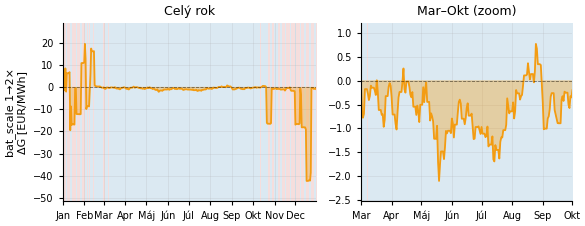

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_daily_gap_change_bat4.jpg


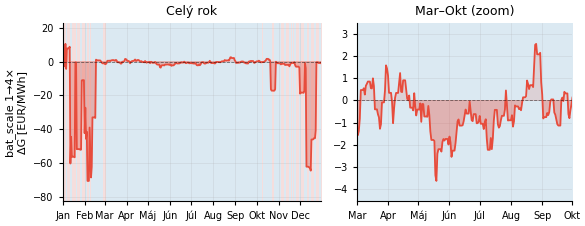

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_daily_gap_change_bat8.jpg


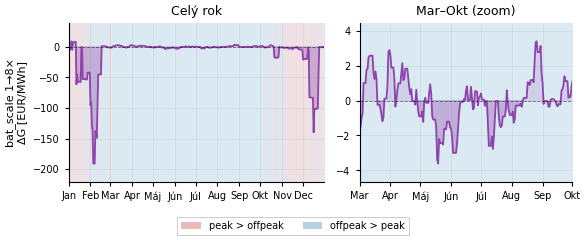

In [64]:
# Daily arbitrage gap change DE00: background = sign(S), line = DeltaG
lmp_all['doy'] = lmp_all['timestamp'].dt.dayofyear
zone = 'DE00'

peak_mean = {}
offpeak_mean = {}
for bs in [1, 2, 4, 8]:
    tags = results[results['battery_scale'] == bs]['tag'].values
    sub = lmp_all[lmp_all['tag'].isin(tags)]
    peak_mean[bs] = sub[sub['is_peak']].groupby(['tag', 'doy'])[zone].mean().groupby('doy').mean()
    offpeak_mean[bs] = sub[~sub['is_peak']].groupby(['tag', 'doy'])[zone].mean().groupby('doy').mean()

signed_s = {bs: (peak_mean[bs] - offpeak_mean[bs]) for bs in [1, 2, 4, 8]}
g_daily = {bs: signed_s[bs].abs() for bs in [1, 2, 4, 8]}

delta_gap = {}
for bs in [2, 4, 8]:
    delta_gap[bs] = (g_daily[bs] - g_daily[1]).rolling(7, center=True, min_periods=1).mean()

s_smooth = signed_s  # no smoothing for structural sign

MAR_START, OCT_END = 60, 274
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','Máj','Jún','Júl','Aug','Sep','Okt','Nov','Dec']
zoom_months = [s for s in month_starts if MAR_START <= s <= OCT_END]
zoom_labels = [month_labels[i] for i, s in enumerate(month_starts) if MAR_START <= s <= OCT_END]

# Colors for background legend (match RdBu_r cmap)
bg_red = plt.cm.RdBu_r(0.85)
bg_blue = plt.cm.RdBu_r(0.15)

for bs in [2, 4, 8]:
    dg = delta_gap[bs]
    s = s_smooth[bs]
    c = SCALE_COLORS[bs]

    fig, axes = thesis_subplots('horizontal_2', nrows=1, ncols=2,
                                 gridspec_kw={'width_ratios': [1.2, 1]})

    for col, (xlim, xticks, xlabels) in enumerate([
        ((1, 365), month_starts, month_labels),
        ((MAR_START, OCT_END), zoom_months, zoom_labels),
    ]):
        ax = axes[col]

        import numpy as np
        s_sub = s[(s.index >= xlim[0]) & (s.index <= xlim[1])]
        bg = np.where(s_sub.values > 0, 1.0, -1.0).reshape(1, -1)
        dg_sub = dg[(dg.index >= xlim[0]) & (dg.index <= xlim[1])]
        ymin_bg = dg_sub.min()
        ymax_bg = dg_sub.max()
        margin_bg = max((ymax_bg - ymin_bg) * 0.15, 0.1)
        ylo, yhi = ymin_bg - margin_bg, ymax_bg + margin_bg

        ax.imshow(bg, aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5,
                  extent=[s_sub.index.min(), s_sub.index.max(), ylo, yhi],
                  alpha=0.18, zorder=0, interpolation='nearest')

        ax.fill_between(dg_sub.index, dg_sub.values, 0,
                        where=dg_sub.values < 0, color=c, alpha=0.35, zorder=1)
        ax.fill_between(dg_sub.index, dg_sub.values, 0,
                        where=dg_sub.values >= 0, color=c, alpha=0.15, zorder=1)
        ax.plot(dg_sub.index, dg_sub.values, color=c, linewidth=1.3, zorder=2)
        ax.axhline(0, color=REFLINE, linewidth=0.6, linestyle='--', alpha=0.5, zorder=2)
        ax.set_xlim(xlim)
        ax.set_ylim(ylo, yhi)
        ax.grid(alpha=0.3, zorder=0)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabels)

        if col == 0:
            ax.set_ylabel(f'bat_scale 1→{bs}×\nΔG [EUR/MWh]')
        ax.set_title('Celý rok' if col == 0 else 'Mar–Okt (zoom)')

    if bs == 8:
        from matplotlib.patches import Patch
        legend_handles = [
            Patch(facecolor=bg_red, alpha=0.35, label='peak > offpeak'),
            Patch(facecolor=bg_blue, alpha=0.35, label='offpeak > peak'),
        ]
        fig.legend(handles=legend_handles, loc='lower center', ncol=2,
                   bbox_to_anchor=(0.5, -0.03), frameon=True, framealpha=0.9)
        plt.tight_layout(rect=[0, 0.08, 1, 1])
    else:
        plt.tight_layout()

    save_fig(fig, f'daily_gap_change_bat{bs}')
    plt.show()


Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_daily_gap_change_eu_bat2.jpg


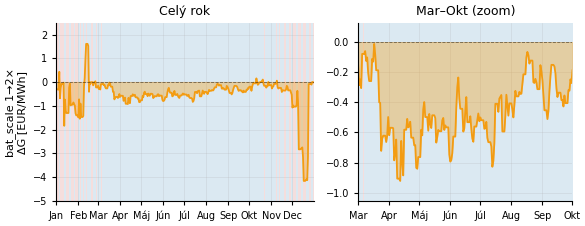

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_daily_gap_change_eu_bat4.jpg


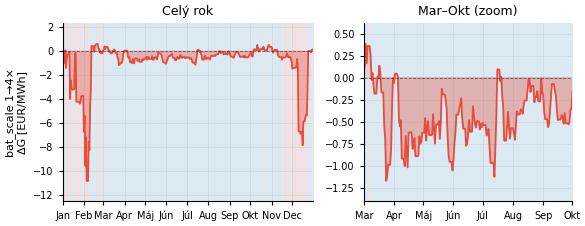

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_daily_gap_change_eu_bat8.jpg


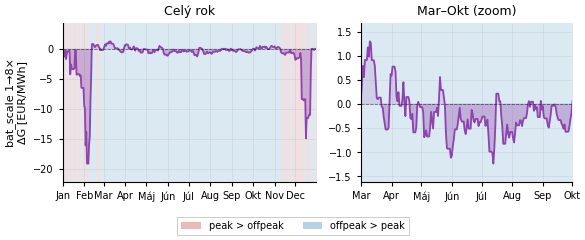

In [65]:
# Daily arbitrage gap change EU mean: background = sign(S), line = DeltaG
lmp_all['doy'] = lmp_all['timestamp'].dt.dayofyear

peak_mean = {}
offpeak_mean = {}
for bs in [1, 2, 4, 8]:
    tags = results[results['battery_scale'] == bs]['tag'].values
    sub = lmp_all[lmp_all['tag'].isin(tags)]
    peak_mean[bs] = sub[sub['is_peak']].groupby(['tag', 'doy'])[bus_cols].mean().mean(axis=1).groupby('doy').mean()
    offpeak_mean[bs] = sub[~sub['is_peak']].groupby(['tag', 'doy'])[bus_cols].mean().mean(axis=1).groupby('doy').mean()

signed_s = {bs: (peak_mean[bs] - offpeak_mean[bs]) for bs in [1, 2, 4, 8]}
g_daily = {bs: signed_s[bs].abs() for bs in [1, 2, 4, 8]}

delta_gap = {}
for bs in [2, 4, 8]:
    delta_gap[bs] = (g_daily[bs] - g_daily[1]).rolling(7, center=True, min_periods=1).mean()

s_smooth = signed_s

MAR_START, OCT_END = 60, 274
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','Máj','Jún','Júl','Aug','Sep','Okt','Nov','Dec']
zoom_months = [s for s in month_starts if MAR_START <= s <= OCT_END]
zoom_labels = [month_labels[i] for i, s in enumerate(month_starts) if MAR_START <= s <= OCT_END]

bg_red = plt.cm.RdBu_r(0.85)
bg_blue = plt.cm.RdBu_r(0.15)

for bs in [2, 4, 8]:
    dg = delta_gap[bs]
    s = s_smooth[bs]
    c = SCALE_COLORS[bs]

    fig, axes = thesis_subplots('horizontal_2', nrows=1, ncols=2,
                                 gridspec_kw={'width_ratios': [1.2, 1]})

    for col, (xlim, xticks, xlabels) in enumerate([
        ((1, 365), month_starts, month_labels),
        ((MAR_START, OCT_END), zoom_months, zoom_labels),
    ]):
        ax = axes[col]

        import numpy as np
        s_sub = s[(s.index >= xlim[0]) & (s.index <= xlim[1])]
        bg = np.where(s_sub.values > 0, 1.0, -1.0).reshape(1, -1)
        dg_sub = dg[(dg.index >= xlim[0]) & (dg.index <= xlim[1])]
        ymin_bg = dg_sub.min()
        ymax_bg = dg_sub.max()
        margin_bg = max((ymax_bg - ymin_bg) * 0.15, 0.1)
        ylo, yhi = ymin_bg - margin_bg, ymax_bg + margin_bg

        ax.imshow(bg, aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5,
                  extent=[s_sub.index.min(), s_sub.index.max(), ylo, yhi],
                  alpha=0.18, zorder=0, interpolation='nearest')

        ax.fill_between(dg_sub.index, dg_sub.values, 0,
                        where=dg_sub.values < 0, color=c, alpha=0.35, zorder=1)
        ax.fill_between(dg_sub.index, dg_sub.values, 0,
                        where=dg_sub.values >= 0, color=c, alpha=0.15, zorder=1)
        ax.plot(dg_sub.index, dg_sub.values, color=c, linewidth=1.3, zorder=2)
        ax.axhline(0, color=REFLINE, linewidth=0.6, linestyle='--', alpha=0.5, zorder=2)
        ax.set_xlim(xlim)
        ax.set_ylim(ylo, yhi)
        ax.grid(alpha=0.3, zorder=0)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabels)

        if col == 0:
            ax.set_ylabel(f'bat_scale 1→{bs}×\nΔG [EUR/MWh]')
        ax.set_title('Celý rok' if col == 0 else 'Mar–Okt (zoom)')

    if bs == 8:
        from matplotlib.patches import Patch
        legend_handles = [
            Patch(facecolor=bg_red, alpha=0.35, label='peak > offpeak'),
            Patch(facecolor=bg_blue, alpha=0.35, label='offpeak > peak'),
        ]
        fig.legend(handles=legend_handles, loc='lower center', ncol=2,
                   bbox_to_anchor=(0.5, -0.03), frameon=True, framealpha=0.9)
        plt.tight_layout(rect=[0, 0.08, 1, 1])
    else:
        plt.tight_layout()

    save_fig(fig, f'daily_gap_change_eu_bat{bs}')
    plt.show()


### DE00 average daily demand profile

Reference daily demand curve for DE00, averaged across climate years. Shows why peak/offpeak hours are structured as they are in the classical market definition.

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_demand_profile_de_eu.jpg


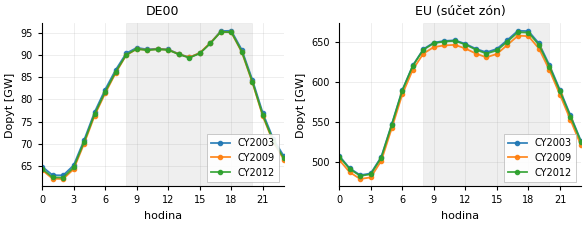

In [ ]:
# DE00 + EU average daily demand profile (TYNDP 2024 NT)
# EU = sum across all zones (naturally demand-weighted aggregate)
demand = pd.read_parquet(ROOT / 'data' / 'tyndp2024' / 'preprocessed' / 'demand_profiles.parquet')

cys = [2003, 2009, 2012]

fig, (ax_de, ax_eu) = thesis_subplots('horizontal_2', nrows=1, ncols=2)

# DE00
de_demand = demand['DE00'].reset_index()
de_demand['hour_of_day'] = de_demand['hour'] % 24
for cy in cys:
    sub = de_demand[de_demand['climate_year'] == cy]
    hourly = sub.groupby('hour_of_day')['DE00'].mean() / 1000  # GW
    ax_de.plot(hourly.index, hourly.values, '-', marker='o', markersize=3,
               linewidth=1.3, label=CY_LABELS[cy], alpha=0.9)
ax_de.axvspan(8, 20, alpha=0.12, color='gray')
ax_de.set_xlabel('hodina')
ax_de.set_ylabel('Dopyt [GW]')
ax_de.set_xticks(range(0, 24, 3))
ax_de.set_xlim(0, 23)
ax_de.set_title('DE00')
ax_de.grid(alpha=0.3)
ax_de.legend(loc='lower right', fontsize=7)

# EU total (sum across all zones per hour)
eu_demand = demand.sum(axis=1).reset_index()
eu_demand.columns = ['climate_year', 'hour', 'demand']
eu_demand['hour_of_day'] = eu_demand['hour'] % 24
for cy in cys:
    sub = eu_demand[eu_demand['climate_year'] == cy]
    hourly = sub.groupby('hour_of_day')['demand'].mean() / 1000  # GW
    ax_eu.plot(hourly.index, hourly.values, '-', marker='o', markersize=3,
               linewidth=1.3, label=CY_LABELS[cy], alpha=0.9)
ax_eu.axvspan(8, 20, alpha=0.12, color='gray')
ax_eu.set_xlabel('hodina')
ax_eu.set_ylabel('Dopyt [GW]')
ax_eu.set_xticks(range(0, 24, 3))
ax_eu.set_xlim(0, 23)
ax_eu.set_title('EU (súčet zón)')
ax_eu.grid(alpha=0.3)
ax_eu.legend(loc='lower right', fontsize=7)

plt.tight_layout()
save_fig(fig, 'demand_profile_de_eu')
plt.show()


### Daily spread change → `fig_daily_spread_change_bat{2,4,8}` (DE00 + EU)

For each day-of-year, compute the change in peak–off-peak spread vs `bat1×` baseline. Left panel: whole year. Right panel: March–October zoom.


In [50]:
# # Spread change DE00: three separate figures
# lmp_all['doy'] = lmp_all['timestamp'].dt.dayofyear
# zone = 'DE00'
# step_colors = {2: '#f39c12', 4: '#e74c3c', 8: '#8e44ad'}

# peak_mean = {}
# offpeak_mean = {}
# for bs in [1, 2, 4, 8]:
#     tags = results[results['battery_scale'] == bs]['tag'].values
#     sub = lmp_all[lmp_all['tag'].isin(tags)]
#     peak_mean[bs] = sub[sub['is_peak']].groupby(['tag', 'doy'])[zone].mean().groupby('doy').mean()
#     offpeak_mean[bs] = sub[~sub['is_peak']].groupby(['tag', 'doy'])[zone].mean().groupby('doy').mean()

# delta_spread = {}
# for bs in [2, 4, 8]:
#     dp = (peak_mean[bs] - peak_mean[1]).rolling(7, center=True, min_periods=1).mean()
#     do = (offpeak_mean[bs] - offpeak_mean[1]).rolling(7, center=True, min_periods=1).mean()
#     delta_spread[bs] = dp - do

# MAR_START, OCT_END = 60, 274
# month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
# month_labels = ['Jan','Feb','Mar','Apr','Máj','Jún','Júl','Aug','Sep','Okt','Nov','Dec']
# zoom_months = [s for s in month_starts if MAR_START <= s <= OCT_END]
# zoom_labels = [month_labels[i] for i, s in enumerate(month_starts) if MAR_START <= s <= OCT_END]

# for bs in [2, 4, 8]:
#     ds = delta_spread[bs]
#     c = step_colors[bs]

#     fig, axes = thesis_subplots('horizontal_2', nrows=1, ncols=2,
#                                  gridspec_kw={'width_ratios': [1.2, 1]})

#     for col, (xlim, xticks, xlabels) in enumerate([
#         ((1, 365), month_starts, month_labels),
#         ((MAR_START, OCT_END), zoom_months, zoom_labels),
#     ]):
#         ax = axes[col]
#         ax.fill_between(ds.index, ds.values, 0, where=ds.values >= 0, color='#e74c3c', alpha=0.3)
#         ax.fill_between(ds.index, ds.values, 0, where=ds.values < 0, color='#3498db', alpha=0.3)
#         ax.plot(ds.index, ds.values, color=c, linewidth=1.2)
#         ax.axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.5)
#         ax.set_xlim(xlim)
#         ax.grid(alpha=0.3)
#         ax.set_xticks(xticks)
#         ax.set_xticklabels(xlabels)

#         if col == 0:
#             ax.set_ylabel(f'bat_scale 1\u2192{bs}\u00d7\n\u0394S [EUR/MWh]')
#         ax.set_title('Celý rok' if col == 0 else 'Mar\u2013Okt (zoom)')

#     # Auto-scale right column
#     zoom_vals = ds[(ds.index >= MAR_START) & (ds.index <= OCT_END)]
#     ymin, ymax = zoom_vals.min(), zoom_vals.max()
#     margin = (ymax - ymin) * 0.15
#     axes[1].set_ylim(ymin - margin, ymax + margin)

#     plt.tight_layout()
#     save_fig(fig, f'daily_spread_change_bat{bs}')
#     plt.show()


In [51]:
# # Spread change EU mean: three separate figures
# lmp_all['doy'] = lmp_all['timestamp'].dt.dayofyear

# step_colors = {2: '#f39c12', 4: '#e74c3c', 8: '#8e44ad'}

# peak_mean = {}
# offpeak_mean = {}
# for bs in [1, 2, 4, 8]:
#     tags = results[results['battery_scale'] == bs]['tag'].values
#     sub = lmp_all[lmp_all['tag'].isin(tags)]
#     peak_mean[bs] = sub[sub['is_peak']].groupby(['tag', 'doy'])[bus_cols].mean().mean(axis=1).groupby('doy').mean()
#     offpeak_mean[bs] = sub[~sub['is_peak']].groupby(['tag', 'doy'])[bus_cols].mean().mean(axis=1).groupby('doy').mean()

# delta_spread = {}
# for bs in [2, 4, 8]:
#     dp = (peak_mean[bs] - peak_mean[1]).rolling(7, center=True, min_periods=1).mean()
#     do = (offpeak_mean[bs] - offpeak_mean[1]).rolling(7, center=True, min_periods=1).mean()
#     delta_spread[bs] = dp - do

# MAR_START, OCT_END = 60, 274
# month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
# month_labels = ['Jan','Feb','Mar','Apr','Máj','Jún','Júl','Aug','Sep','Okt','Nov','Dec']
# zoom_months = [s for s in month_starts if MAR_START <= s <= OCT_END]
# zoom_labels = [month_labels[i] for i, s in enumerate(month_starts) if MAR_START <= s <= OCT_END]

# for bs in [2, 4, 8]:
#     ds = delta_spread[bs]
#     c = step_colors[bs]

#     fig, axes = thesis_subplots('horizontal_2', nrows=1, ncols=2,
#                                  gridspec_kw={'width_ratios': [1.2, 1]})

#     for col, (xlim, xticks, xlabels) in enumerate([
#         ((1, 365), month_starts, month_labels),
#         ((MAR_START, OCT_END), zoom_months, zoom_labels),
#     ]):
#         ax = axes[col]
#         ax.fill_between(ds.index, ds.values, 0, where=ds.values >= 0, color='#e74c3c', alpha=0.3)
#         ax.fill_between(ds.index, ds.values, 0, where=ds.values < 0, color='#3498db', alpha=0.3)
#         ax.plot(ds.index, ds.values, color=c, linewidth=1.2)
#         ax.axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.5)
#         ax.set_xlim(xlim)
#         ax.grid(alpha=0.3)
#         ax.set_xticks(xticks)
#         ax.set_xticklabels(xlabels)

#         if col == 0:
#             ax.set_ylabel(f'bat_scale 1\u2192{bs}\u00d7\n\u0394S [EUR/MWh]')
#         ax.set_title('Celý rok' if col == 0 else 'Mar\u2013Okt (zoom)')

#     # Auto-scale right column
#     zoom_vals = ds[(ds.index >= MAR_START) & (ds.index <= OCT_END)]
#     ymin, ymax = zoom_vals.min(), zoom_vals.max()
#     margin = (ymax - ymin) * 0.15
#     axes[1].set_ylim(ymin - margin, ymax + margin)

#     plt.tight_layout()
#     save_fig(fig, f'daily_spread_change_eu_bat{bs}')
#     plt.show()


### Technology capture rates → `fig_capture_rates_line`

Capture rate = technology volume-weighted price / system average price. Computed for solar-pv-utility, onwind, offwind across `bat_scale` levels.


In [52]:
# Capture rate computation (data already loaded in the setup cell)
cr_records = []

for i, tag in enumerate(results["tag"].values):
    lmp_tag = lmp_all[lmp_all["tag"] == tag][bus_cols].values  # 8760 x 55
    gen_tag = gen_p_all[gen_p_all["tag"] == tag][gen_cols].values  # 8760 x 557

    # System average price (generation-weighted)
    total_gen_per_zone = np.zeros(len(bus_cols))
    for gi, gname in enumerate(gen_cols):
        if gname in static_gen.index:
            bus = static_gen.loc[gname, "bus"]
            if bus in bus_cols:
                bi = bus_cols.index(bus)
                total_gen_per_zone[bi] += gen_tag[:, gi].sum()

    sys_price = np.sum(lmp_tag.mean(axis=0) * total_gen_per_zone) / total_gen_per_zone.sum() if total_gen_per_zone.sum() > 0 else np.nan

    for carrier in KEY_CARRIERS:
        units = static_gen[static_gen["carrier"] == carrier].index
        units_in = [u for u in units if u in gen_cols]
        if not units_in:
            continue

        total_revenue = 0
        total_generation = 0
        for u in units_in:
            gi = gen_cols.index(u)
            bus = static_gen.loc[u, "bus"]
            if bus not in bus_cols:
                continue
            bi = bus_cols.index(bus)
            gen_u = gen_tag[:, gi]
            lmp_u = lmp_tag[:, bi]
            total_revenue += (gen_u * lmp_u).sum()
            total_generation += gen_u.sum()

        if total_generation > 0 and sys_price > 0:
            capture_price = total_revenue / total_generation
            cr = capture_price / sys_price
            cr_records.append({"tag": tag, "carrier": carrier, "capture_rate": cr,
                              "capture_price": capture_price, "sys_price": sys_price})

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

cr_df = pd.DataFrame(cr_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)
print(f"Capture rate data: {len(cr_df)} rows")
print(f"\nMean capture rate by carrier:")
print(cr_df.groupby("carrier")["capture_rate"].mean().round(3).sort_values(ascending=False))

  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...
Capture rate data: 2592 rows

Mean capture rate by carrier:
carrier
gas                 1.619
nuclear             1.082
hydro-ror           1.078
onwind              0.810
offwind             0.746
solar-pv-utility    0.694
Name: capture_rate, dtype: float64


  100/432
  200/432
  300/432
  400/432
DE00 CR: 1296 records


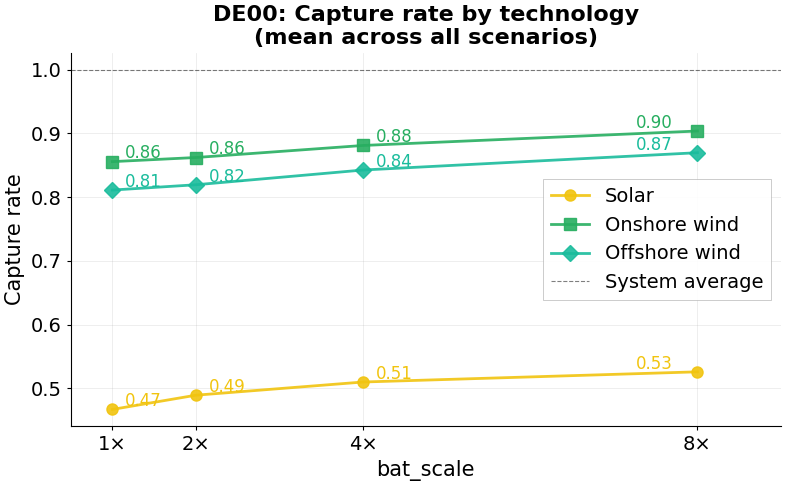

In [53]:
# Capture rate line plot — DE00
# Compute CR per carrier for DE00 only

carriers_plot = ['solar-pv-utility', 'onwind', 'offwind']
carrier_labels = {'solar-pv-utility': 'Solar', 'onwind': 'Onshore wind', 'offwind': 'Offshore wind'}
carrier_colors_cr = {'solar-pv-utility': '#f1c40f', 'onwind': '#27ae60', 'offwind': '#1abc9c'}
carrier_markers_cr = {'solar-pv-utility': 'o', 'onwind': 's', 'offwind': 'D'}

cr_de_records = []
de_idx = bus_cols.index('DE00')

for i, tag in enumerate(results['tag'].values):
    lmp_tag = lmp_all[lmp_all['tag'] == tag]['DE00'].values
    gen_tag = gen_p_all[gen_p_all['tag'] == tag]
    sys_avg = lmp_tag.mean()
    if sys_avg == 0:
        continue
    bs = results.iloc[i]['battery_scale']
    
    for carrier in carriers_plot:
        gens = static_gen[(static_gen['carrier'] == carrier) & 
                         (static_gen['bus'] == 'DE00')].index
        gen_cols_c = [g for g in gens if g in gen_cols]
        if not gen_cols_c:
            continue
        gen_output = gen_tag[gen_cols_c].sum(axis=1).values
        total_gen = gen_output.sum()
        if total_gen == 0:
            continue
        weighted_price = (lmp_tag * gen_output).sum() / total_gen
        cr_de_records.append({'bat_scale': bs, 'carrier': carrier, 'cr': weighted_price / sys_avg})
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/432')

cr_de = pd.DataFrame(cr_de_records)
cr_de_agg = cr_de.groupby(['bat_scale', 'carrier'])['cr'].mean().reset_index()
print(f'DE00 CR: {len(cr_de)} records')

fig, ax = plt.subplots(figsize=(8, 5))

for carrier in carriers_plot:
    sub = cr_de_agg[cr_de_agg['carrier'] == carrier]
    ax.plot(sub['bat_scale'], sub['cr'], '-',
            color=carrier_colors_cr[carrier], marker=carrier_markers_cr[carrier],
            markersize=8, linewidth=2, label=carrier_labels[carrier], alpha=0.9)
    for _, r in sub.iterrows():
        xoff = -0.3 if r['bat_scale'] == 8 else 0.15
        ha = 'right' if r['bat_scale'] == 8 else 'left'
        ax.text(r['bat_scale'] + xoff, r['cr'] + 0.005, f'{r["cr"]:.2f}',
                fontsize=12, color=carrier_colors_cr[carrier], ha=ha)

ax.axhline(1.0, color='k', linewidth=0.8, linestyle='--', alpha=0.5, label='System average')
ax.set_xlabel('bat_scale', fontsize=15)
ax.set_ylabel('Capture rate', fontsize=15)
ax.set_xticks([1, 2, 4, 8])
ax.set_xticklabels(['1×', '2×', '4×', '8×'])
ax.set_xlim(0.5, 9)
ax.tick_params(axis='both', labelsize=14)
ax.set_title('DE00: Capture rate by technology\n'
             '(mean across all scenarios)',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_capture_rates_line.jpg


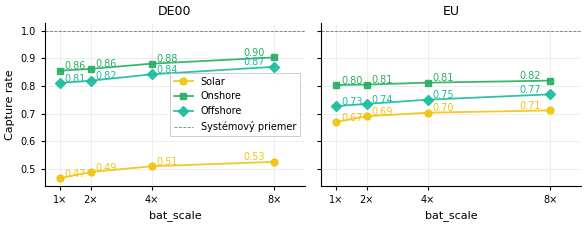

In [54]:
# Capture rate \u2014 DE00 + EU side by side
cr_eu_agg = cr_df[cr_df['carrier'].isin(carriers_plot)].groupby(
    ['battery_scale', 'carrier'])['capture_rate'].mean().reset_index()

carrier_labels_sk = {
    'solar-pv-utility': 'Solar',
    'onwind':           'Onshore',
    'offwind':          'Offshore',
}
carrier_colors_cr = {
    'solar-pv-utility': CARRIER_COLORS['solar'],
    'onwind':           CARRIER_COLORS['onwind'],
    'offwind':          CARRIER_COLORS['offwind'],
}
carrier_markers_cr = {'solar-pv-utility': 'o', 'onwind': 's', 'offwind': 'D'}

fig, (ax1, ax2) = thesis_subplots('horizontal_2', nrows=1, ncols=2, sharey=True)

for ax, df, title, bs_col in [
    (ax1, cr_de_agg, 'DE00', 'bat_scale'),
    (ax2, cr_eu_agg, 'EU',   'battery_scale'),
]:
    for carrier in carriers_plot:
        sub = df[df['carrier'] == carrier]
        cr_col = 'cr' if 'cr' in sub.columns else 'capture_rate'
        ax.plot(sub[bs_col], sub[cr_col], '-',
                color=carrier_colors_cr[carrier],
                marker=carrier_markers_cr[carrier],
                markersize=5, linewidth=1.3,
                label=carrier_labels_sk[carrier], alpha=0.9)
        for _, r in sub.iterrows():
            xoff = -0.3 if r[bs_col] == 8 else 0.15
            ha = 'right' if r[bs_col] == 8 else 'left'
            ax.text(r[bs_col] + xoff, r[cr_col] + 0.005, f'{r[cr_col]:.2f}',
                    color=carrier_colors_cr[carrier], ha=ha, fontsize=7)

    ax.axhline(1.0, color='k', linewidth=0.6, linestyle='--', alpha=0.5,
               label='Systémový priemer')
    ax.set_xlabel('bat_scale')
    ax.set_xticks([1, 2, 4, 8])
    ax.set_xticklabels([SCALE_LABELS[bs] for bs in [1, 2, 4, 8]])
    ax.set_xlim(0.5, 9)
    ax.set_title(title)
    ax.grid(alpha=0.3)

ax1.set_ylabel('Capture rate')
ax1.legend(loc='right')

plt.tight_layout()
save_fig(fig, 'capture_rates_line')
plt.show()


## Chapter 8 — Battery economics


### LCOS model (Ember 2025)

CAPEX = 125 EUR/kWh, lifetime = 20 yr, discount = 7%, degradation = 2%/yr, OpEx = 2% CAPEX/yr, round-trip η = 0.92. Builds `lcos_all` with arbitrage spread, LCOS and profit per (scenario, DE00/EU).


In [55]:
# LCOS analysis — DE00 + EU mean, aggregated across CY
# Ember (2025): CAPEX=125 EUR/kWh, lifetime=20yr, discount=7%, degradation=2%/yr, OpEx=2%/yr
# Effective spread (with RTE correction)
# LCOS with discounting and degradation per LaTeX formula

CAPEX_KWH = 125  # EUR/kWh
CAPEX_MWH = CAPEX_KWH * 1000  # EUR/MWh for consistent units with spread
LIFETIME = 20  # years
DISCOUNT = 0.07
DEGRADATION = 0.02
OPEX_RATE = 0.02  # fraction of CAPEX per year

def compute_lcos(annual_cycles, capex=CAPEX_MWH, lifetime=LIFETIME, r=DISCOUNT, d=DEGRADATION, opex=OPEX_RATE):
    """LCOS with discounting, degradation and OpEx (EUR/MWh)"""
    e_npv = 0
    opex_npv = 0
    for y in range(1, lifetime + 1):
        e_npv += annual_cycles * (1 - d) ** y / (1 + r) ** y
        opex_npv += capex * opex / (1 + r) ** y
    if e_npv == 0:
        return 9999
    return (capex + opex_npv) / e_npv

bat_units = static_su[static_su['carrier'] == 'battery']
bat_cols_l = [c for c in stor_cols if c in bat_units.index]
bat_info = bat_units.loc[bat_cols_l, ['p_nom', 'max_hours']].copy()

# Compute for ALL scenarios (all CY, gas, co2)
lcos_records = []
for i, row in enumerate(results.itertuples()):
    tag = row.tag
    bs = row.battery_scale
    dur = row.battery_duration
    
    stor_tag = stor_p_all[stor_p_all['tag'] == tag]
    lmp_tag = lmp_all[lmp_all['tag'] == tag]
    
    # EU mean LMP and DE00 LMP
    lmp_eu = lmp_tag[bus_cols].mean(axis=1).values
    lmp_de = lmp_tag['DE00'].values
    
    for zone_label, lmp_vals in [('DE00', lmp_de), ('EU_mean', lmp_eu)]:
        total_discharge = 0
        total_charge = 0
        total_revenue = 0
        total_cost = 0
        total_e_cap = 0
        
        # Only use battery units in the relevant zone
        if zone_label == 'DE00':
            units_to_use = [u for u in bat_cols_l if bat_units.loc[u, 'bus'] == 'DE00']
        else:
            units_to_use = bat_cols_l
        
        for unit in units_to_use:
            power = stor_tag[unit].values
            e_cap = bat_info.loc[unit, 'p_nom'] * bs * bat_info.loc[unit, 'max_hours'] * dur
            if e_cap <= 0:
                continue
            
            discharge = np.where(power > 0, power, 0)
            charge = np.where(power < 0, -power, 0)
            
            total_discharge += discharge.sum()
            total_charge += charge.sum()
            total_revenue += (discharge * lmp_vals).sum()
            total_cost += (charge * lmp_vals).sum()
            total_e_cap += e_cap
        
        if total_discharge == 0 or total_e_cap == 0:
            continue
        
        avg_sell = total_revenue / total_discharge
        avg_buy = total_cost / total_charge
        rte_ratio = total_charge / total_discharge
        effective_spread = avg_sell - avg_buy * rte_ratio
        annual_cycles = total_discharge / total_e_cap
        lcos = compute_lcos(annual_cycles)
        
        lcos_records.append({
            'zone': zone_label, 'bat_scale': bs, 'bat_duration': dur,
            'climate_year': row.climate_year, 'gas_price': row.gas_price, 'co2_price': row.co2_price,
            'annual_cycles': annual_cycles, 'spread': effective_spread,
            'lcos': lcos, 'profit': effective_spread - lcos,
            'avg_sell': avg_sell, 'avg_buy': avg_buy,
        })
    
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/432')

lcos_all = pd.DataFrame(lcos_records)
print(f'LCOS data: {len(lcos_all)} records')




  50/432
  100/432
  150/432
  200/432
  250/432
  300/432
  350/432
  400/432
LCOS data: 864 records


### LCOS grid for DE00 → `fig_lcos_de00`

3×3 heatmap (CY rows × metric cols): arbitrage spread, LCOS, profit.


lcos_agg: 48 rows
Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_lcos_de00.jpg


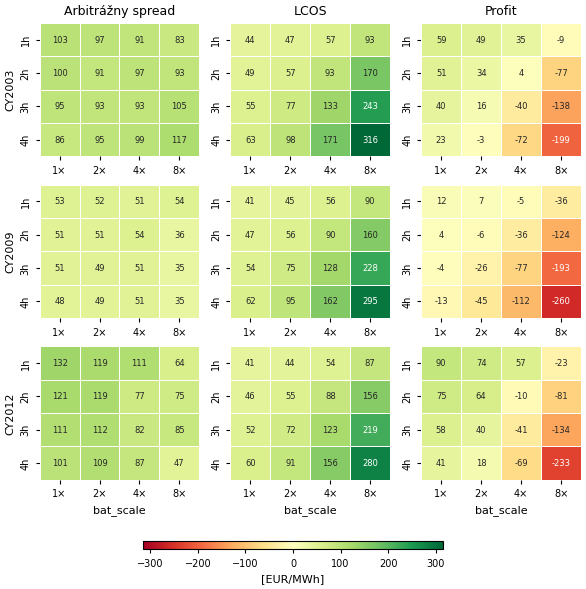

In [56]:
# LCOS analysis grid \u2014 DE00 only: rows = CY, cols = (spread, LCOS, profit)
lcos_agg = lcos_all[lcos_all['zone'] == 'DE00'].groupby(
    ['zone', 'bat_scale', 'bat_duration', 'climate_year']).agg(
    spread=('spread', 'mean'), lcos=('lcos', 'mean'), profit=('profit', 'mean'),
    annual_cycles=('annual_cycles', 'mean')
).reset_index()
print(f'lcos_agg: {len(lcos_agg)} rows')

all_vals = pd.concat([lcos_agg['spread'], lcos_agg['lcos'], lcos_agg['profit']])
vabs = max(abs(all_vals.min()), abs(all_vals.max()))

import matplotlib.colors as mcolors
norm = mcolors.TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)

fig, axes = thesis_subplots('grid_3x3', nrows=3, ncols=3, figsize=(6.0, 5.8))

for row_idx, cy in enumerate([2003, 2009, 2012]):
    sub = lcos_agg[lcos_agg['climate_year'] == cy]

    for col_idx, (col, title) in enumerate([
        ('spread', 'Arbitrážny spread'),
        ('lcos',   'LCOS'),
        ('profit', 'Profit'),
    ]):
        ax = axes[row_idx, col_idx]
        pivot = sub.pivot(index='bat_duration', columns='bat_scale', values=col)
        pivot = pivot.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])

        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
                    annot_kws={'fontsize': 6},
                    linewidths=0.4, norm=norm, cbar=False,
                    xticklabels=[SCALE_LABELS[bs] for bs in [1, 2, 4, 8]],
                    yticklabels=[f'{d}h' for d in [1, 2, 3, 4]])

        ax.set_xlabel('bat_scale' if row_idx == 2 else '')
        if col_idx == 0:
            ax.set_ylabel(CY_LABELS[cy])
        else:
            ax.set_ylabel('')
        if row_idx == 0:
            ax.set_title(title)

plt.tight_layout()
fig.subplots_adjust(bottom=0.16)

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.015])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label('[EUR/MWh]')

save_fig(fig, 'lcos_de00')
plt.show()


### Daily LMP profile → `fig_de00_daily_profile_curves` + `fig_de00_daily_profile_areas`

Two 1×3 figures (one panel per climate year):

- Curves: average daily LMP profile in DE00 for each `bat_scale`, grey band = solar hours 9–14h
- Bars: area under the curve inside the solar-hour window (uses `math.ceil` so 4× and 8× — which differ by <0.2 — display the same rounded value)


CY2003: 1x=245.331, 2x=259.131, 4x=278.004, 8x=278.893
CY2009: 1x=241.544, 2x=249.596, 4x=253.008, 8x=253.529
CY2012: 1x=218.283, 2x=228.445, 4x=232.539, 8x=232.417
Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_de00_daily_profile_curves.jpg


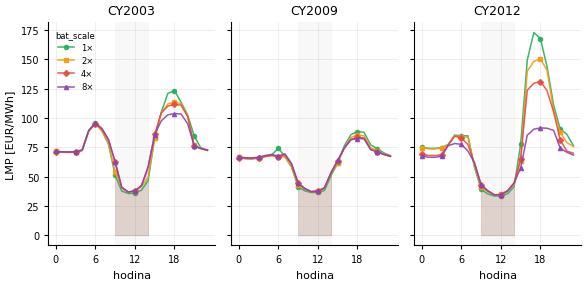

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_de00_daily_profile_areas.jpg


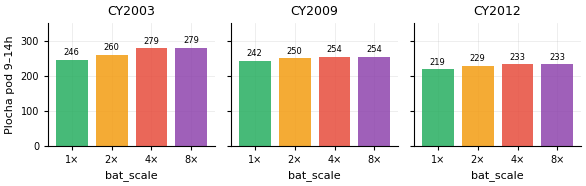

In [57]:
import math
# DE00: daily LMP profile + area under 9-14h — two 1x3 figures (curves / bars)
lmp_all['hour'] = lmp_all['timestamp'].dt.hour
bat_scales = [1, 2, 4, 8]
cys = [2003, 2009, 2012]

# Precompute
per_cy_hourly = {}
per_cy_areas = {}
for cy in cys:
    hourly_by_bs = {}
    areas = {}
    for bs in bat_scales:
        tags = results[(results['battery_scale'] == bs) &
                       (results['battery_duration'] == 1) &
                       (results['climate_year'] == cy)]['tag'].values
        sub = lmp_all[lmp_all['tag'].isin(tags)]
        hourly = sub.groupby('hour')['DE00'].mean()
        hourly_by_bs[bs] = hourly
        areas[bs] = hourly[(hourly.index >= 9) & (hourly.index <= 14)].sum()
    per_cy_hourly[cy] = hourly_by_bs
    per_cy_areas[cy] = areas

for cy in cys:
    print(f"CY{cy}: " + ", ".join(f"{bs}x={per_cy_areas[cy][bs]:.3f}" for bs in bat_scales))

# --- Figure 1: daily LMP profiles (1x3 per climate year) ---
fig, axes = thesis_subplots('horizontal_3', nrows=1, ncols=3,
                             figsize=(6.0, 3.0), sharey=True)
for k, cy in enumerate(cys):
    ax = axes[k]
    for bs in bat_scales:
        hourly = per_cy_hourly[cy][bs]
        ax.plot(hourly.index, hourly.values, '-',
                color=SCALE_COLORS[bs], marker=SCALE_MARKERS[bs],
                markersize=3, linewidth=1.1, markevery=3,
                label=SCALE_LABELS[bs], alpha=0.9)
        zoom = hourly[(hourly.index >= 9) & (hourly.index <= 14)]
        ax.fill_between(zoom.index, zoom.values, 0,
                        color=SCALE_COLORS[bs], alpha=0.08)
    ax.set_title(CY_LABELS[cy])
    ax.set_xticks(range(0, 24, 6))
    ax.grid(alpha=0.3)
    ax.axvspan(9, 14, alpha=0.05, color='gray')
    ax.set_xlabel('hodina')
    if k == 0:
        ax.set_ylabel('LMP [EUR/MWh]')

axes[0].legend(loc='upper left', fontsize=6, title='bat_scale',
               title_fontsize=6, frameon=False)
plt.tight_layout()
save_fig(fig, 'de00_daily_profile_curves')
plt.show()

# --- Figure 2: area under LMP curve in 9-14h window (1x3) ---
fig, axes = thesis_subplots('horizontal_3', nrows=1, ncols=3,
                             figsize=(6.0, 2), sharey=True)
for k, cy in enumerate(cys):
    ax = axes[k]
    areas = per_cy_areas[cy]
    bar_colors = [SCALE_COLORS[bs] for bs in bat_scales]
    ax.bar(range(len(bat_scales)), [areas[bs] for bs in bat_scales],
           color=bar_colors, alpha=0.85)
    ax.set_xticks(range(len(bat_scales)))
    ax.set_xticklabels([SCALE_LABELS[bs] for bs in bat_scales], fontsize=7)
    ax.set_xlabel('bat_scale')
    ax.set_title(CY_LABELS[cy])
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 350)
    ax.set_yticks([0, 100, 200, 300])
    if k == 0:
        ax.set_ylabel('Plocha pod 9–14h')
    for j, bs in enumerate(bat_scales):
        ax.text(j, areas[bs] + 8, f'{math.ceil(areas[bs])}',
                ha='center', va='bottom', fontsize=6)

plt.tight_layout()
save_fig(fig, 'de00_daily_profile_areas')
plt.show()


### Per-zone profitability → `fig_lcos_mega` & `fig_lcos_zoom`

`zone_agg` computes LCOS profit per zone for every (bat_scale, bat_duration, CY, gas_price, co2_price) combination.

- **Mega:** 9×3 grid over gas×co2 rows and CY columns, green cells = profitable
- **Zoom:** gas=35, CY2012 slice stacked by co2 levels for readability


In [58]:
# LCOS profitability: per-zone data computation (all bat/dur combos)

zone_lcos_records = []
for i, row in enumerate(results.itertuples()):
    tag = row.tag
    bs = row.battery_scale
    dur = row.battery_duration
    stor_tag = stor_p_all[stor_p_all['tag'] == tag]
    lmp_tag = lmp_all[lmp_all['tag'] == tag]
    
    for zone in bus_cols:
        lmp_vals = lmp_tag[zone].values
        zone_units = bat_units[bat_units['bus'] == zone].index
        zone_bat = [c for c in bat_cols_l if c in zone_units]
        if not zone_bat:
            continue
        
        td, tc, tr, tco, te = 0, 0, 0, 0, 0
        for unit in zone_bat:
            power = stor_tag[unit].values
            e_cap = bat_info.loc[unit, 'p_nom'] * bs * bat_info.loc[unit, 'max_hours'] * dur
            if e_cap <= 0: continue
            dis = np.where(power > 0, power, 0)
            ch = np.where(power < 0, -power, 0)
            td += dis.sum(); tc += ch.sum()
            tr += (dis * lmp_vals).sum(); tco += (ch * lmp_vals).sum()
            te += e_cap
        
        if td == 0 or te == 0: continue
        eff_spread = tr/td - tco/tc * (tc/td)
        ac = td / te
        lcos = compute_lcos(ac)
        zone_lcos_records.append({
            'zone': zone, 'climate_year': row.climate_year,
            'gas_price': row.gas_price, 'co2_price': row.co2_price,
            'bat_scale': bs, 'bat_duration': dur,
            'profit': eff_spread - lcos,
        })
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/432')

zone_lcos = pd.DataFrame(zone_lcos_records)
zone_agg = zone_lcos.copy()
zone_agg['combo'] = zone_agg['bat_scale'].astype(str) + '×' + zone_agg['bat_duration'].astype(str) + 'h'
print(f'Data ready: {len(zone_agg)} rows')

  50/432
  100/432
  150/432
  200/432
  250/432
  300/432
  350/432
  400/432
Data ready: 15120 rows


/var/folders/kr/02s80h4x0pn0rxjq93w2tjz00000gn/T/ipykernel_59938/599718933.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_lcos_mega.jpg


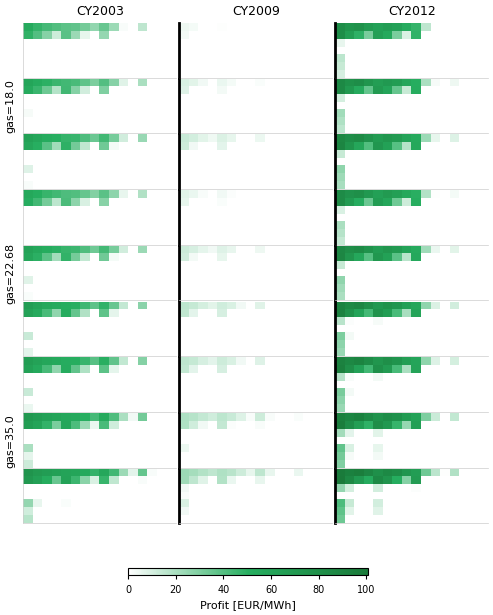

In [59]:
# LCOS mega-heatmap: profitable zones across all 432 scenarios
import matplotlib.colors as mcolors

combo_order = [f'{bs}\u00d7{dur}h' for bs in [1, 2, 4, 8] for dur in [1, 2, 3, 4]]
zone_agg['combo'] = zone_agg['bat_scale'].astype(str) + '\u00d7' + zone_agg['bat_duration'].astype(str) + 'h'

cmap = mcolors.LinearSegmentedColormap.from_list('profit', ['white', '#27ae60', '#1a7a3a'])
vmax = max(zone_agg[zone_agg['profit'] > 0]['profit'].max(), 1)

all_profitable = zone_agg[zone_agg['profit'] > 0]['zone'].unique()
rank = zone_agg[zone_agg['zone'].isin(all_profitable)].groupby('zone')['profit'].mean().sort_values(ascending=False)
zone_list = rank.index.tolist()

gas_prices = [18.0, 22.68, 35.0]
co2_prices = [80.0, 113.4, 140.0]
cy_list = [2003, 2009, 2012]

fig, axes = thesis_subplots('full_page', nrows=9, ncols=3,
                             gridspec_kw={'hspace': 0.02, 'wspace': 0.02})

for row_idx, (gas, co2) in enumerate([(g, c) for g in gas_prices for c in co2_prices]):
    for col_idx, cy in enumerate(cy_list):
        ax = axes[row_idx, col_idx]
        sub = zone_agg[(zone_agg['gas_price'] == gas) & (zone_agg['co2_price'] == co2) &
                       (zone_agg['climate_year'] == cy) & (zone_agg['zone'].isin(zone_list))]

        pivot = sub.pivot(index='zone', columns='combo', values='profit')
        pivot = pivot.reindex(index=zone_list, columns=combo_order)
        pivot_show = pivot.clip(lower=0).values

        ax.imshow(pivot_show, aspect='auto', cmap=cmap, vmin=0, vmax=vmax,
                  interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(CY_LABELS[cy])

        if col_idx == 0 and row_idx % 3 == 1:
            ax.set_ylabel(f'gas={gas}', labelpad=6)

        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
            spine.set_color('#ccc')

# Thick separators between gas groups
for row_idx in [3, 6]:
    for col_idx in range(3):
        axes[row_idx, col_idx].spines['top'].set_linewidth(2)
        axes[row_idx, col_idx].spines['top'].set_color('black')

# Thick separators between CY columns
for row_idx in range(9):
    for col_idx in [1, 2]:
        axes[row_idx, col_idx].spines['left'].set_linewidth(2)
        axes[row_idx, col_idx].spines['left'].set_color('black')

plt.tight_layout(rect=[0, 0.06, 1, 1])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
cbar_ax = fig.add_axes([0.3, 0.03, 0.4, 0.012])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label('Profit [EUR/MWh]')

save_fig(fig, 'lcos_mega')
plt.show()


/var/folders/kr/02s80h4x0pn0rxjq93w2tjz00000gn/T/ipykernel_59938/3148183971.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_lcos_zoom.jpg


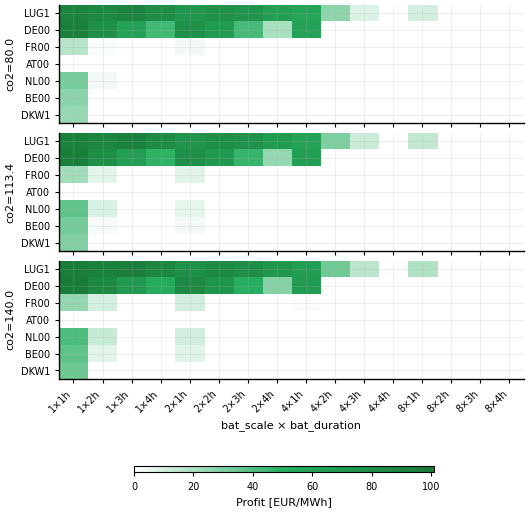

In [60]:
# Zoom: fixed gas + CY, 3 co2 values stacked
import matplotlib.colors as mcolors

ZOOM_GAS = 35.0
ZOOM_CY = 2012

combo_order = [f'{bs}\u00d7{dur}h' for bs in [1, 2, 4, 8] for dur in [1, 2, 3, 4]]
cmap = mcolors.LinearSegmentedColormap.from_list('profit', ['white', '#27ae60', '#1a7a3a'])

sub_gas = zone_agg[zone_agg['gas_price'] == ZOOM_GAS]
prof_zones = sub_gas[sub_gas['profit'] > 0]['zone'].unique()
rank = sub_gas[sub_gas['zone'].isin(prof_zones)].groupby('zone')['profit'].mean().sort_values(ascending=False)
z_list = rank.index.tolist()

if len(z_list) == 0:
    print('No profitable zones')
else:
    fig, axes = thesis_subplots('stacked_3', nrows=3, ncols=1, figsize=(6.0, 5.5),
                                 sharex=True, sharey=True,
                                 gridspec_kw={'hspace': 0.08})

    for row, co2 in enumerate([80.0, 113.4, 140.0]):
        ax = axes[row]
        sub = zone_agg[(zone_agg['gas_price'] == ZOOM_GAS) & (zone_agg['co2_price'] == co2) &
                       (zone_agg['climate_year'] == ZOOM_CY) & (zone_agg['zone'].isin(z_list))]

        pivot = sub.pivot(index='zone', columns='combo', values='profit')
        pivot = pivot.reindex(index=z_list, columns=combo_order)
        pivot_show = pivot.clip(lower=0).values

        ax.imshow(pivot_show, aspect='auto', cmap=cmap, vmin=0, vmax=vmax,
                  interpolation='nearest')

        ax.set_yticks(range(len(z_list)))
        ax.set_yticklabels(z_list)
        ax.set_ylabel(f'co2={co2}')

        if row == 2:
            ax.set_xticks(range(len(combo_order)))
            ax.set_xticklabels(combo_order, rotation=45, ha='right')
            ax.set_xlabel('bat_scale \u00d7 bat_duration')
        else:
            ax.set_xticks([])

        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            spine.set_color('black')

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.2)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
    cbar_ax = fig.add_axes([0.25, 0.03, 0.5, 0.012])
    cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cb.set_label('Profit [EUR/MWh]')

    save_fig(fig, 'lcos_zoom')
    plt.show()
